# Warehouse Monitoring - ML Analysis: **LAS Project**  

---

# Project context

This work is part of the **Smart Warehouse Monitoring System** realized during the first LAS, supervised by Dr. Joseph AZAR. The project addresses a practical and industrially relevant problem: how can an IoT-equipped warehouse automatically detect environmental and operational risks that may damage stored goods?

This notebook analyzes data from a **Smart Warehouse Monitoring System** designed to monitor storage conditions inside a warehouse zone. The project combines embedded sensing, IoT communication, rule-based alerting, and data visualization.

The system monitors several operational and environmental risks that may damage stored goods:
- abnormal temperature and humidity,
- mechanical impacts or shocks,
- water leaks,
- item identification using RFID,
- estimated storage weight and alert severity.

The original project architecture uses Arduino Nano 33 IoT boards and an ESP32 for sensing and alert display, Node-RED for processing and rule logic, InfluxDB for time-series storage, and Grafana for visualization.

# Project aim
The machine learning component of this notebook goes one step further: instead of relying solely on hard-coded threshold rules, we investigate whether data-driven models can detect anomalies and predict alert states from sensor readings, and whether learned decision boundaries can provide more robust and generalizable monitoring behavior.

# Real and synthetic data
This project contains both **real measured data** and **derived / synthetic variables**:

The dataset contains **1,700 samples** across **12 columns**, covering five distinct warehouse scenarios recorded at 1-second resolution.

**Columns:** time, temperature, humidity, moisture, vibration, item_type, item_count, rfid_code, weight, scenario, alert, alert_name

## Real sensed variables
These values are produced by physical sensors on the Arduino Nano 33 IoT boards:
- **temperature** (°C) — DHT sensor
- **humidity** (%) — DHT sensor
- **moisture** (ADC value, 0–1023) — analog moisture sensor
- **vibration** (G) — onboard accelerometer, X/Y/Z resultant
- **item_type / rfid_code / item_count** — RFID reader identifying item category (NORMAL or FRAGILE) and count

## Derived / synthetic variables
These variables are computed by Node-RED logic, not physically measured:
- **weight** (kg) — total estimated zone weight: NORMAL item adds +5 kg, FRAGILE item adds +2 kg
- **alert** / **alert_name** — GREEN / YELLOW / RED state derived from threshold rules in Flow 2lert labels represent **engineered variables** built on top of system logic.

# Why augmentation is used
Because the original LAS data mostly represents normal operation and the project setup is currently unavailable for new acquisitions, an augmented dataset was prepared externally. This augmented CSV preserves the real baseline ranges but adds realistic fault cases such as:
- high temperature / humidity drift,
- water leak events,
- impact events,
- combined fault situations.

This allows us to test supervised and unsupervised ML methods in a realistic academic setting while clearly stating that some scenarios are simulated.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.svm import OneClassSVM
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")


## 1. Load Dataset


In [5]:
CSV_PATH = 'warehouse_augmented.csv'

df = pd.read_csv(CSV_PATH, parse_dates=['time'])
print('Shape:', df.shape)
print(df.head())
print('Columns:', list(df.columns))


Shape: (1700, 12)
                 time  temperature   humidity     moisture  vibration  \
0 2025-12-16 22:48:00    19.574507  49.513977   998.001796   1.015704   
1 2025-12-16 22:48:01    19.479260  46.155669   993.564756   1.009818   
2 2025-12-16 22:48:02    19.597153  49.739212   997.978380   1.007875   
3 2025-12-16 22:48:03    19.728454  50.711276  1001.346384   1.005459   
4 2025-12-16 22:48:04    19.464877  48.826870   997.390881   1.004591   

  item_type  item_count rfid_code  weight scenario  alert alert_name  
0    NORMAL           3   N-3-370      12   NORMAL      0      GREEN  
1    NORMAL           3   N-3-120      12   NORMAL      0      GREEN  
2    NORMAL           3   N-3-314      12   NORMAL      0      GREEN  
3    NORMAL           3   N-3-472      12   NORMAL      0      GREEN  
4    NORMAL           3   N-3-869      15   NORMAL      0      GREEN  
Columns: ['time', 'temperature', 'humidity', 'moisture', 'vibration', 'item_type', 'item_count', 'rfid_code', 'weight

## 2. Dataset Description

The dataset includes:
- **Physical sensor readings**: temperature, humidity, moisture, vibration
- **RFID-derived variables**: item_type (NORMAL / FRAGILE), item_count, rfid_code
- **Synthetic / derived variables**: weight (computed from RFID type), alert label, scenario label


In [6]:
print(df.dtypes)
print('Scenario counts:')
print(df['scenario'].value_counts())
print('Alert counts:')
print(df['alert_name'].value_counts())
print('Item type counts:')
print(df['item_type'].value_counts())


time           datetime64[ns]
temperature           float64
humidity              float64
moisture              float64
vibration             float64
item_type              object
item_count              int64
rfid_code              object
weight                  int64
scenario               object
alert                   int64
alert_name             object
dtype: object
Scenario counts:
scenario
NORMAL            600
HIGH_TEMP         300
WATER_LEAK        300
IMPACT            300
COMBINED_FAULT    200
Name: count, dtype: int64
Alert counts:
alert_name
GREEN     1029
RED        501
YELLOW     170
Name: count, dtype: int64
Item type counts:
item_type
NORMAL     1240
FRAGILE     460
Name: count, dtype: int64


## 3. Feature Selection Strategy

We keep two possible analysis settings:
1. **Physical-only features**: temperature, humidity, moisture, vibration
2. **Extended features**: physical features + weight + item_count + encoded item_type

The first setting is more scientifically clean because it uses only physical sensing.
The second setting is useful to test whether derived logistics variables improve performance.


In [7]:
physical_features = ['temperature', 'humidity', 'moisture', 'vibration']
extended_features = ['temperature', 'humidity', 'moisture', 'vibration', 'weight', 'item_count']

df['item_type_bin'] = df['item_type'].map({'NORMAL': 0, 'FRAGILE': 1})
extended_features_plus = extended_features + ['item_type_bin']

print('Physical features:', physical_features)
print('Extended features:', extended_features_plus)


Physical features: ['temperature', 'humidity', 'moisture', 'vibration']
Extended features: ['temperature', 'humidity', 'moisture', 'vibration', 'weight', 'item_count', 'item_type_bin']


## 4. Exploratory Data Analysis

We visualize the distribution of each feature per scenario using boxplots. This reveals which sensors discriminate between scenarios and helps interpret the ML results later.


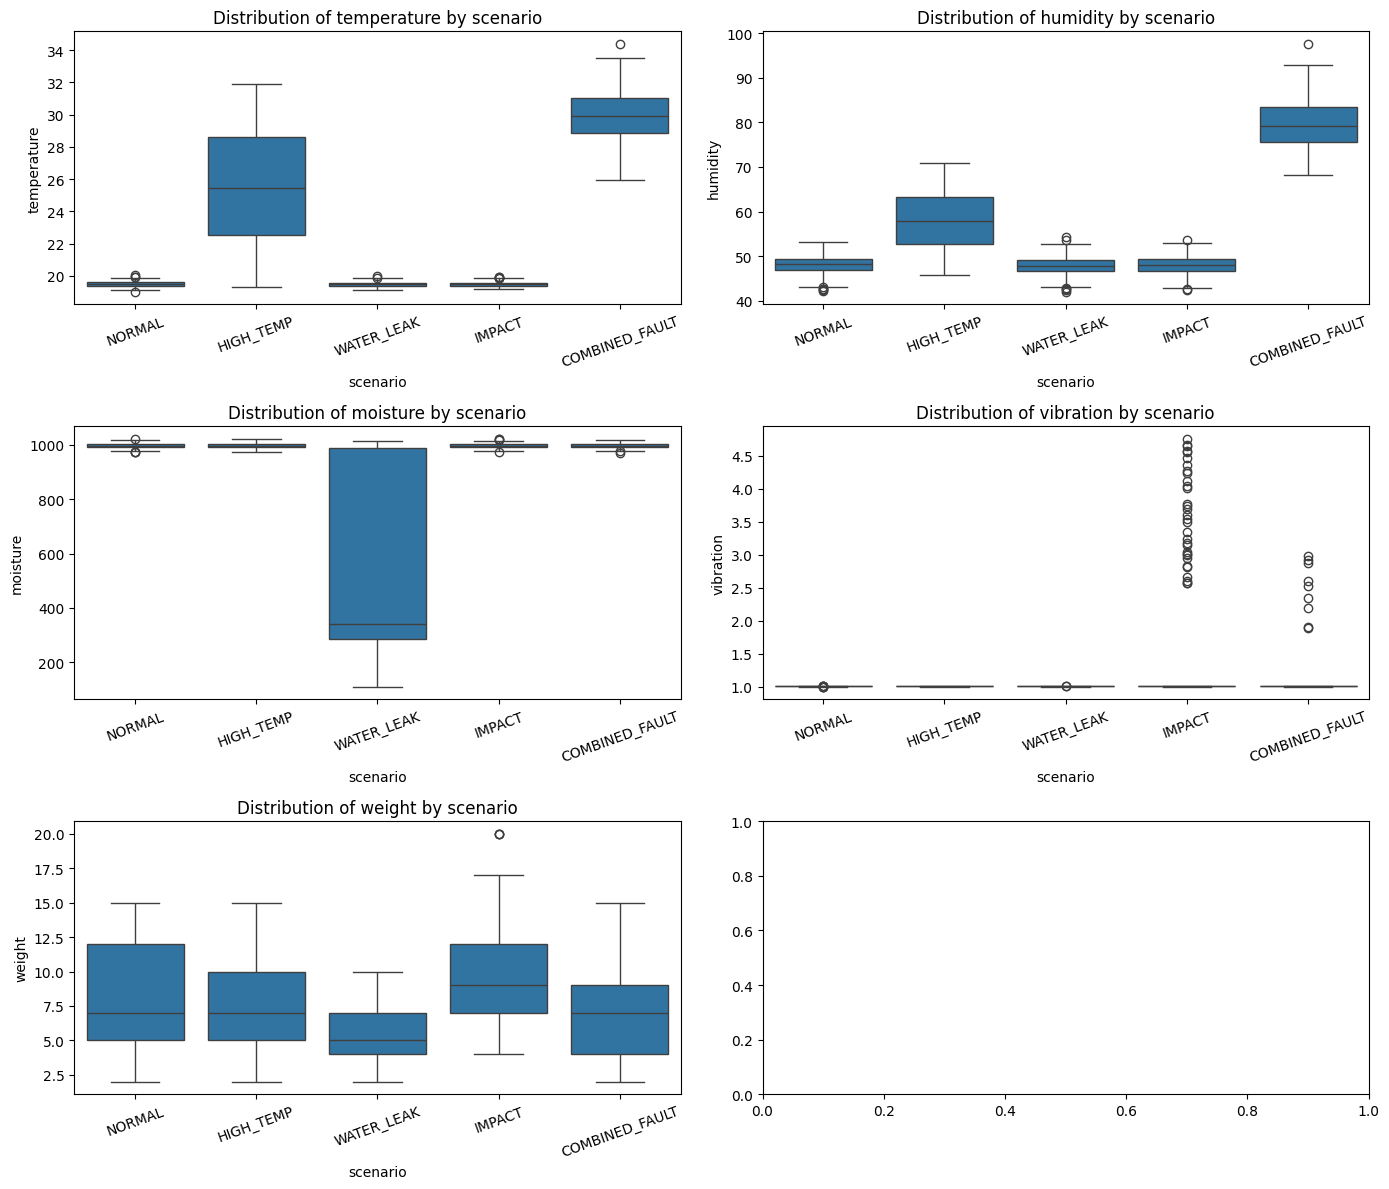

In [8]:
features_to_plot = ['temperature', 'humidity', 'moisture', 'vibration', 'weight']
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    sns.boxplot(data=df, x='scenario', y=feat, ax=axes[i])
    axes[i].set_title(f'Distribution of {feat} by scenario')
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


The boxplot distributions confirm that each scenario produces clearly distinct signal ranges for at least one feature, which is a good prerequisite for learning-based approaches.

- **Temperature**: separates HIGH_TEMP (IQR 22–28°C) and COMBINED_FAULT (~30°C) from all other scenarios (~19.5°C).
- **Humidity**: HIGH_TEMP reaches 55–65% and COMBINED_FAULT peaks at 80%, while all others stay near 48%.
- **Moisture**: WATER_LEAK is the most visually dramatic — values drop from ~997 to as low as ~100 ADC, resulting in a wide IQR with a very low median (~350). All other scenarios stay near 997.
- **Vibration**: IMPACT and COMBINED_FAULT show scattered high-value outliers (up to 4.6G), while all other scenarios are tightly concentrated at 1.01G.
- **Weight**: distributions are largely overlapping across scenarios, which is consistent with the fact that weight is determined by item count and category (NORMAL/FRAGILE) rather than by physical conditions. This already hints that weight will have low predictive power for alert classification.

## 5. Approach 1 — Unsupervised Anomaly Detection

This approach is **unsupervised**: no alert labels are used during training.

The models learn what a "normal" warehouse looks like from the NORMAL samples only, then flag any reading that deviates significantly from that learned profile.

Two methods are compared:

| Method | Principle | Strength |
|---|---|---|
| **Isolation Forest** | Randomly partitions features; anomalies are isolated faster | Better recall (catches more faults) |
| **One-Class SVM** | Learns a boundary around normal data in kernel space | Better precision (fewer false alarms) |

> **Why this matters**: In a real warehouse, you may not have labeled fault events. Unsupervised anomaly detection lets you deploy a monitoring system from day one, using only normal operation data.


In [9]:
X_normal = df[df['scenario'] == 'NORMAL'][physical_features].values
X_all = df[physical_features].values
y_true_anomaly = (df['scenario'] != 'NORMAL').astype(int).values

scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
X_all_scaled = scaler.transform(X_all)

iso = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
iso.fit(X_normal_scaled)
iso_pred = (iso.predict(X_all_scaled) == -1).astype(int)

ocsvm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
ocsvm.fit(X_normal_scaled)
svm_pred = (ocsvm.predict(X_all_scaled) == -1).astype(int)

print('=== Isolation Forest ===')
print(classification_report(y_true_anomaly, iso_pred, target_names=['Normal', 'Anomaly']))
print('=== One-Class SVM ===')
print(classification_report(y_true_anomaly, svm_pred, target_names=['Normal', 'Anomaly']))


=== Isolation Forest ===
              precision    recall  f1-score   support

      Normal       0.62      0.85      0.72       600
     Anomaly       0.90      0.72      0.80      1100

    accuracy                           0.77      1700
   macro avg       0.76      0.79      0.76      1700
weighted avg       0.80      0.77      0.77      1700

=== One-Class SVM ===
              precision    recall  f1-score   support

      Normal       0.62      0.95      0.75       600
     Anomaly       0.96      0.69      0.80      1100

    accuracy                           0.78      1700
   macro avg       0.79      0.82      0.78      1700
weighted avg       0.84      0.78      0.79      1700



## 6. Approach 2 — Supervised Alert Classification

Here we use the **alert label** (GREEN / YELLOW / RED) as the prediction target. This is a 3-class classification problem.

Three models are evaluated with 5-fold stratified cross-validation and a 75/25 train/test split:

| Model | Type | Notes |
|---|---|---|
| **Logistic Regression** | Linear classifier | Fast, interpretable, serves as baseline |
| **Random Forest** | Ensemble of decision trees | Handles non-linear boundaries, robust |
| **Gradient Boosting** | Sequential tree boosting | Often the strongest model for tabular data |

Both feature sets (physical-only and extended) are tested to compare the contribution of synthetic variables.


In [10]:
def evaluate_models(feature_list, title):
    X = df[feature_list].values
    y = df['alert'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y)

    models = {
        'Logistic Regression': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=500))]),
        'Random Forest': RandomForestClassifier(n_estimators=120, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=120, random_state=42),
    }

    print(f'\n===== {title} =====')
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv = cross_val_score(model, X, y, cv=StratifiedKFold(5), scoring='f1_weighted').mean()
        print(f'\n{name} | CV weighted F1 = {cv:.3f}')
        print(classification_report(y_test, y_pred, target_names=['GREEN', 'YELLOW', 'RED']))

    return models, X_train, X_test, y_train, y_test

models_phys, Xtr_p, Xte_p, ytr_p, yte_p = evaluate_models(physical_features, 'Physical-only features')
models_ext, Xtr_e, Xte_e, ytr_e, yte_e = evaluate_models(extended_features_plus, 'Extended features including weight/item category')



===== Physical-only features =====

Logistic Regression | CV weighted F1 = 0.949
              precision    recall  f1-score   support

       GREEN       1.00      1.00      1.00       257
      YELLOW       1.00      0.81      0.90        43
         RED       0.94      1.00      0.97       125

    accuracy                           0.98       425
   macro avg       0.98      0.94      0.96       425
weighted avg       0.98      0.98      0.98       425


Random Forest | CV weighted F1 = 0.975
              precision    recall  f1-score   support

       GREEN       1.00      1.00      1.00       257
      YELLOW       1.00      1.00      1.00        43
         RED       1.00      1.00      1.00       125

    accuracy                           1.00       425
   macro avg       1.00      1.00      1.00       425
weighted avg       1.00      1.00      1.00       425


Gradient Boosting | CV weighted F1 = 0.975
              precision    recall  f1-score   support

       GREEN     

## 7. Feature Importance

Random Forest provides a built-in importance score for each feature, reflecting how much each variable reduces impurity across all decision splits.

This ranking answers a key question: **which sensor signals drive alert classification?**




temperature      0.376967
moisture         0.302672
humidity         0.235129
vibration        0.059861
weight           0.012653
item_count       0.010394
item_type_bin    0.002325
dtype: float64


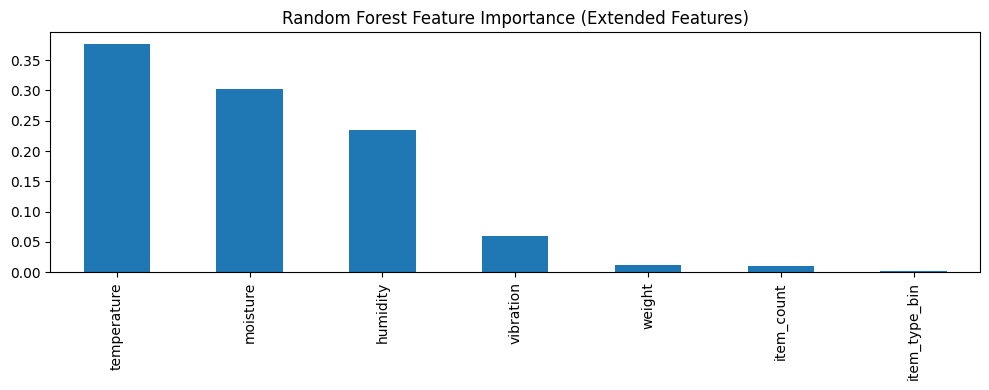

In [11]:
rf_ext = models_ext['Random Forest']
fi = pd.Series(rf_ext.feature_importances_, index=extended_features_plus).sort_values(ascending=False)
print(fi)
fi.plot(kind='bar', figsize=(10,4), title='Random Forest Feature Importance (Extended Features)')
plt.tight_layout()
plt.show()


## 8. Confusion Matrices

Confusion matrices show the exact breakdown of correct and incorrect predictions per class. We display them side by side for physical-only vs. extended features to make the comparison direct.

A perfect matrix has values only on the diagonal (no off-diagonal misclassifications).


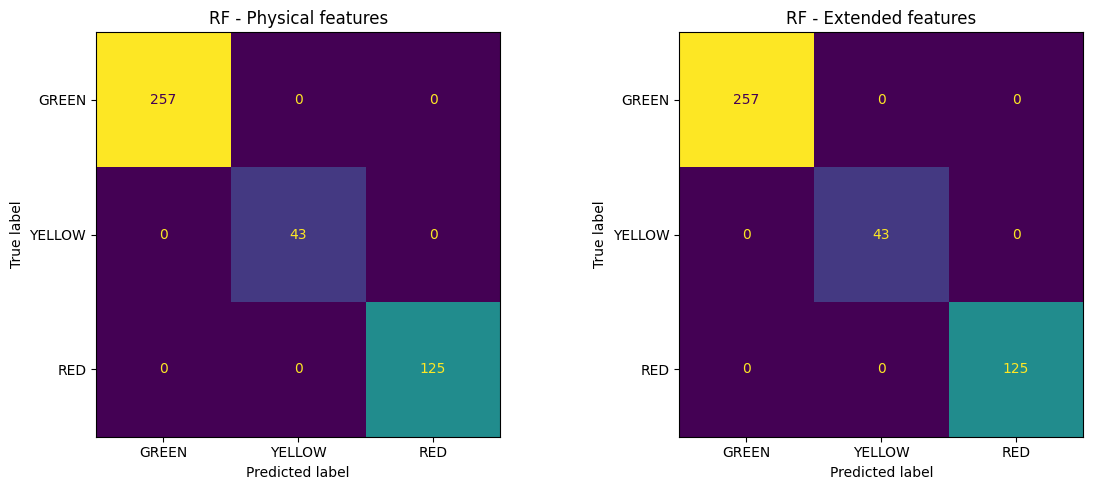

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(yte_p, models_phys['Random Forest'].predict(Xte_p),
                                        display_labels=['GREEN','YELLOW','RED'], ax=axes[0], colorbar=False)
axes[0].set_title('RF - Physical features')
ConfusionMatrixDisplay.from_predictions(yte_e, models_ext['Random Forest'].predict(Xte_e),
                                        display_labels=['GREEN','YELLOW','RED'], ax=axes[1], colorbar=False)
axes[1].set_title('RF - Extended features')
plt.tight_layout()
plt.show()


## 9. PCA Projection

Principal Component Analysis (PCA) reduces the 6-dimensional extended feature space to 2 dimensions for visualization. This reveals the geometric structure of the data and how well scenarios separate in feature space.



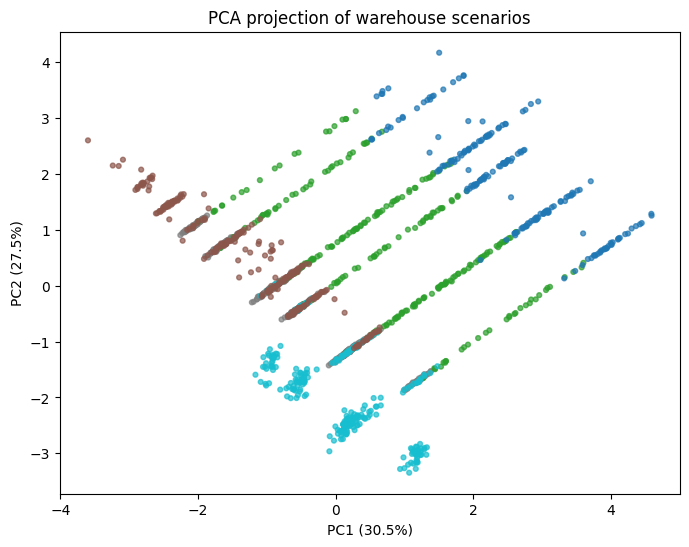

In [13]:
scaler2 = StandardScaler()
X_pca_input = scaler2.fit_transform(df[extended_features_plus].values)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pca_input)

scenario_codes = pd.Categorical(df['scenario']).codes
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=scenario_codes, cmap='tab10', s=12, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA projection of warehouse scenarios')
plt.show()


## 10. KMeans Clustering

KMeans attempts to discover k=5 groups in the data **without using any labels**. We compare the cluster assignments to the true scenario labels to evaluate how naturally the data self-organizes.


In [14]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = km.fit_predict(X_pca_input)
print('Cluster distribution:')
print(pd.Series(clusters).value_counts().sort_index())


Cluster distribution:
0    314
1    599
2    551
3     36
4    200
Name: count, dtype: int64


## 11. LSTM Autoencoder — Temporal Anomaly Detection

A **sequence-based approach** using a deep learning model.

**How it works:**
1. Sliding windows of 30 consecutive readings are created
2. An LSTM Encoder compresses each window into a latent vector
3. An LSTM Decoder reconstructs the original window from that vector
4. The model is trained **only on NORMAL sequences** to minimize reconstruction error
5. On new data: high reconstruction error = the sequence is abnormal

**Why this is better for temporal faults**: methods like Isolation Forest treat each reading independently. The LSTM captures *how the signal evolves over time*, making it much more sensitive to gradual drifts (e.g., temperature rising slowly over 5 minutes in HIGH_TEMP) that look individually normal but are abnormal as a sequence.


LSTM threshold: 1.2500895688539846
              precision    recall  f1-score   support

      Normal       0.88      0.99      0.93       570
     Anomaly       0.99      0.93      0.96      1100

    accuracy                           0.95      1670
   macro avg       0.94      0.96      0.94      1670
weighted avg       0.95      0.95      0.95      1670



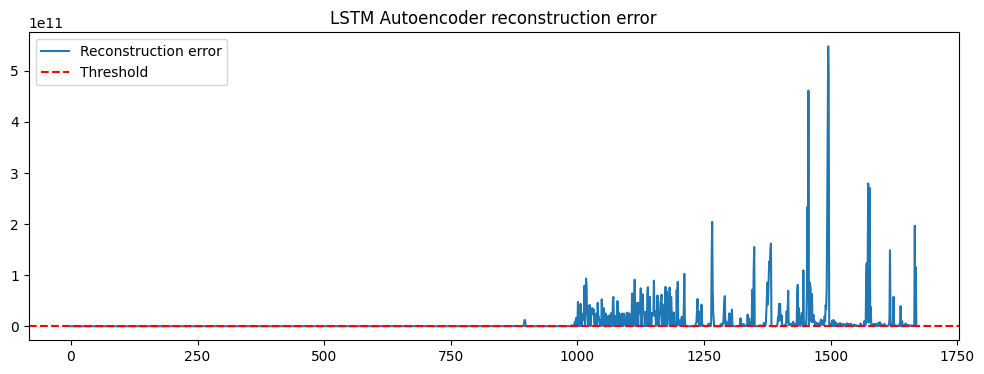

In [15]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
    from tensorflow.keras.callbacks import EarlyStopping

    SEQ_LEN = 30
    seq_features = physical_features

    def create_sequences(data, seq_len):
        return np.array([data[i:i+seq_len] for i in range(len(data)-seq_len)])

    X_norm = df[df['scenario']=='NORMAL'][seq_features].values
    X_all_seq_input = df[seq_features].values

    sc = StandardScaler()
    X_norm_sc = sc.fit_transform(X_norm)
    X_all_sc = sc.transform(X_all_seq_input)

    X_norm_seq = create_sequences(X_norm_sc, SEQ_LEN)
    X_all_seq = create_sequences(X_all_sc, SEQ_LEN)
    y_seq_true = (df['scenario'].values[SEQ_LEN:] != 'NORMAL').astype(int)

    inp = Input(shape=(SEQ_LEN, len(seq_features)))
    enc = LSTM(32, activation='relu', return_sequences=False)(inp)
    rep = RepeatVector(SEQ_LEN)(enc)
    dec = LSTM(32, activation='relu', return_sequences=True)(rep)
    out = TimeDistributed(Dense(len(seq_features)))(dec)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='mse')

    Xtr, Xval = train_test_split(X_norm_seq, test_size=0.1, random_state=42)
    model.fit(Xtr, Xtr, validation_data=(Xval, Xval), epochs=25, batch_size=32,
              callbacks=[EarlyStopping(patience=4, restore_best_weights=True)], verbose=0)

    pred = model.predict(X_all_seq, verbose=0)
    mse = np.mean(np.mean((X_all_seq - pred)**2, axis=2), axis=1)
    threshold = np.percentile(mse[:len(X_norm_seq)], 99)
    y_pred_seq = (mse > threshold).astype(int)

    print('LSTM threshold:', threshold)
    print(classification_report(y_seq_true, y_pred_seq, target_names=['Normal','Anomaly']))

    plt.figure(figsize=(12,4))
    plt.plot(mse, label='Reconstruction error')
    plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
    plt.legend()
    plt.title('LSTM Autoencoder reconstruction error')
    plt.show()

except Exception as e:
    print('LSTM section skipped:', e)


## 12. Robustness Test — Model Stability Under Sensor Noise

A perfect test accuracy of 1.00 raises a legitimate question: is this because the model is genuinely robust, or because the synthetic data is too clean?

To answer this, we deliberately inject **Gaussian noise** into the test features at increasing levels (1% to 20% of the feature standard deviation) and measure how accuracy degrades. A robust model should maintain high accuracy under moderate noise.

This test simulates real-world conditions such as sensor drift, electrical interference, or calibration errors.


 Noise level (σ fraction)  RF Accuracy
                     0.00       1.0000
                     0.01       1.0000
                     0.05       0.9976
                     0.10       0.9929
                     0.20       0.9788
                     0.40       0.8941


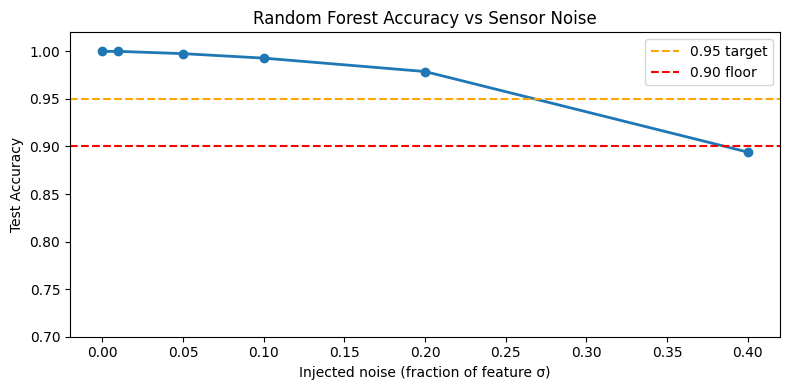

In [16]:
# ── Robustness test: accuracy under increasing Gaussian noise ──
import numpy as np

X_phys = df[physical_features].values
y_alert = df['alert'].values
X_tr, X_te, y_tr, y_te = train_test_split(X_phys, y_alert, test_size=0.25, random_state=42, stratify=y_alert)

rf_robust = RandomForestClassifier(n_estimators=120, random_state=42)
rf_robust.fit(X_tr, y_tr)

noise_levels = [0.0, 0.01, 0.05, 0.10, 0.20, 0.40]
feature_std  = X_te.std(axis=0)
results_noise = []

for noise in noise_levels:
    X_noisy = X_te + np.random.default_rng(0).normal(0, noise, X_te.shape) * feature_std
    acc = rf_robust.score(X_noisy, y_te)
    results_noise.append({'Noise level (σ fraction)': noise, 'RF Accuracy': round(acc, 4)})

noise_df = pd.DataFrame(results_noise)
print(noise_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(noise_df['Noise level (σ fraction)'], noise_df['RF Accuracy'], marker='o', linewidth=2)
plt.axhline(0.95, color='orange', linestyle='--', label='0.95 target')
plt.axhline(0.90, color='red',    linestyle='--', label='0.90 floor')
plt.xlabel('Injected noise (fraction of feature σ)')
plt.ylabel('Test Accuracy')
plt.title('Random Forest Accuracy vs Sensor Noise')
plt.legend()
plt.ylim(0.7, 1.02)
plt.tight_layout()
plt.show()


## 13. YELLOW Class Analysis — Decision Boundary Visualization

YELLOW is the most academically interesting alert state: it represents a **transitional zone** between normal and critical conditions. Logistic Regression misclassified some YELLOW samples as RED (recall 0.81), revealing that the YELLOW boundary is non-linearly separable.

This cell:
1. Prints the per-class misclassification breakdown across all three models
2. Visualizes the **2D decision boundary** of the Random Forest in the temperature–moisture space, showing exactly where GREEN, YELLOW, and RED regions lie


Per-model YELLOW recall and precision:

  Logistic Regression       | YELLOW precision=1.00  recall=0.81  F1=0.90
  Random Forest             | YELLOW precision=1.00  recall=1.00  F1=1.00
  Gradient Boosting         | YELLOW precision=1.00  recall=1.00  F1=1.00


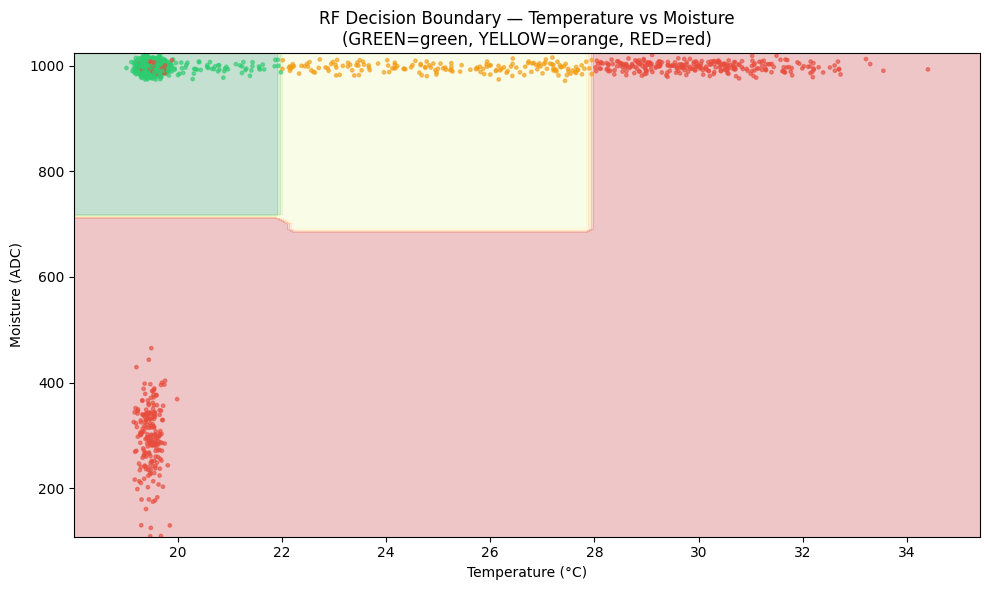

In [17]:
# ── Per-class YELLOW misclassification analysis ──
from sklearn.inspection import DecisionBoundaryDisplay

X_phys = df[physical_features].values
y_alert = df['alert'].values
X_tr, X_te, y_tr, y_te = train_test_split(X_phys, y_alert, test_size=0.25,
                                           random_state=42, stratify=y_alert)

# Label encoder for display
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_tr_enc = le.fit_transform(y_tr)
y_te_enc  = le.transform(y_te)
class_names = le.classes_

print("Per-model YELLOW recall and precision:\n")
for name, model in models_phys.items():
    y_pred = model.predict(X_te)
    report = classification_report(y_te, y_pred, target_names=['GREEN','YELLOW','RED'],
                                   output_dict=True)
    y_prec = report['YELLOW']['precision']
    y_rec  = report['YELLOW']['recall']
    y_f1   = report['YELLOW']['f1-score']
    print(f"  {name:25s} | YELLOW precision={y_prec:.2f}  recall={y_rec:.2f}  F1={y_f1:.2f}")

# Decision boundary in temperature vs moisture 2D slice
temp_idx = physical_features.index('temperature')
mois_idx = physical_features.index('moisture')

X_2d = X_phys[:, [temp_idx, mois_idx]]
y_2d = le.transform(y_alert)
rf_2d = RandomForestClassifier(n_estimators=120, random_state=42)
rf_2d.fit(X_2d, y_2d)

fig, ax = plt.subplots(figsize=(10, 6))
colors_scatter = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
color_list = [colors_scatter[c] for c in y_2d]
DecisionBoundaryDisplay.from_estimator(
    rf_2d, X_2d, response_method='predict',
    cmap=plt.cm.RdYlGn_r, alpha=0.25, ax=ax)
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=color_list, s=6, alpha=0.6)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Moisture (ADC)')
ax.set_title('RF Decision Boundary — Temperature vs Moisture\n(GREEN=green, YELLOW=orange, RED=red)')
plt.tight_layout()
plt.show()


## 14. Leave-One-Scenario-Out Generalization Test

Standard train/test split mixes all scenarios in both sets, which may inflate accuracy if the model just memorizes each scenario's signal range.

A stricter test: **train on 4 scenarios, evaluate on the held-out 5th**. This measures whether the model can generalize to a fault type it has **never seen during training** — the most realistic deployment condition.

- If accuracy remains high → the model has learned general alert-level boundaries
- If accuracy drops on a specific scenario → that scenario has unique signal characteristics that require explicit training examples


Held-out scenario  Test samples  Logistic Regression F1  Random Forest F1  Gradient Boosting F1
        HIGH_TEMP           300                   0.346             0.460                 0.388
       WATER_LEAK           300                   0.167             0.167                 0.167
           IMPACT           300                   0.843             0.843                 0.843
   COMBINED_FAULT           200                   0.853             1.000                 1.000


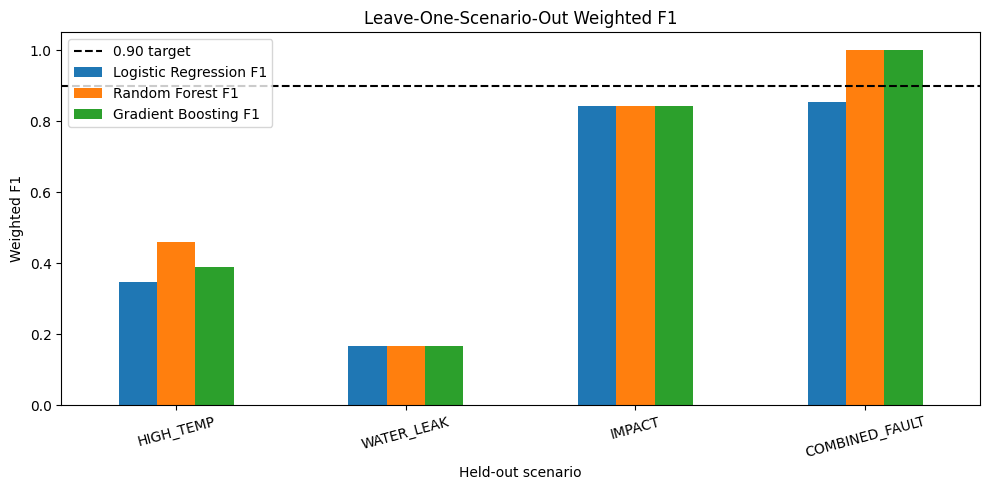

In [18]:
# ── Leave-One-Scenario-Out cross-validation ──
from sklearn.metrics import f1_score

scenarios = ['HIGH_TEMP', 'WATER_LEAK', 'IMPACT', 'COMBINED_FAULT']
loso_results = []

for held_out in scenarios:
    train_df = df[df['scenario'] != held_out]
    test_df  = df[df['scenario'] == held_out]

    X_tr_lo = train_df[physical_features].values
    y_tr_lo = train_df['alert'].values
    X_te_lo = test_df[physical_features].values
    y_te_lo = test_df['alert'].values

    row = {'Held-out scenario': held_out, 'Test samples': len(test_df)}
    for name, ModelClass in [
        ('Logistic Regression',  lambda: Pipeline([('sc', StandardScaler()),
                                                    ('clf', LogisticRegression(max_iter=500))])),
        ('Random Forest',        lambda: RandomForestClassifier(n_estimators=120, random_state=42)),
        ('Gradient Boosting',    lambda: GradientBoostingClassifier(n_estimators=120, random_state=42))
    ]:
        m = ModelClass()
        m.fit(X_tr_lo, y_tr_lo)
        y_pred_lo = m.predict(X_te_lo)
        f1 = f1_score(y_te_lo, y_pred_lo, average='weighted')
        row[name + ' F1'] = round(f1, 3)

    loso_results.append(row)

loso_df = pd.DataFrame(loso_results)
print(loso_df.to_string(index=False))

loso_df.set_index('Held-out scenario')[['Logistic Regression F1',
                                         'Random Forest F1',
                                         'Gradient Boosting F1']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1.05))
plt.axhline(0.9, color='black', linestyle='--', label='0.90 target')
plt.title('Leave-One-Scenario-Out Weighted F1')
plt.ylabel('Weighted F1')
plt.xlabel('Held-out scenario')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()


## 15. Zone Risk Score — Combining Physical and Cargo Risk

 Standard environmental monitoring (temperature, moisture, vibration) tells us *how dangerous the conditions are*. The RFID system tells us *what is at risk* — FRAGILE items are more damage-prone than NORMAL ones.

We combine both dimensions into a **Zone Risk Index**:

`risk_score = alert_level × (1 + 0.5 × fragility) × item_count`

Where:
- `alert_level` = 0 (GREEN), 1 (YELLOW), 2 (RED)
- `fragility` = 1 if FRAGILE, 0 if NORMAL
- `item_count` = number of items in the zone

This creates a **composite risk signal** that escalates when dangerous conditions coincide with fragile, high-quantity cargo — a genuinely actionable warehouse metric.


Risk score statistics per scenario:
                count  mean   std  min  25%  50%  75%   max
scenario                                                   
COMBINED_FAULT  200.0  4.89  2.54  1.0  3.0  4.0  6.0   9.0
HIGH_TEMP       300.0  2.24  1.95  0.0  1.0  2.0  3.0   9.0
IMPACT          300.0  0.70  2.17  0.0  0.0  0.0  0.0  12.0
NORMAL          600.0  0.00  0.00  0.0  0.0  0.0  0.0   0.0
WATER_LEAK      300.0  2.23  1.86  0.0  0.0  2.0  4.0   6.0


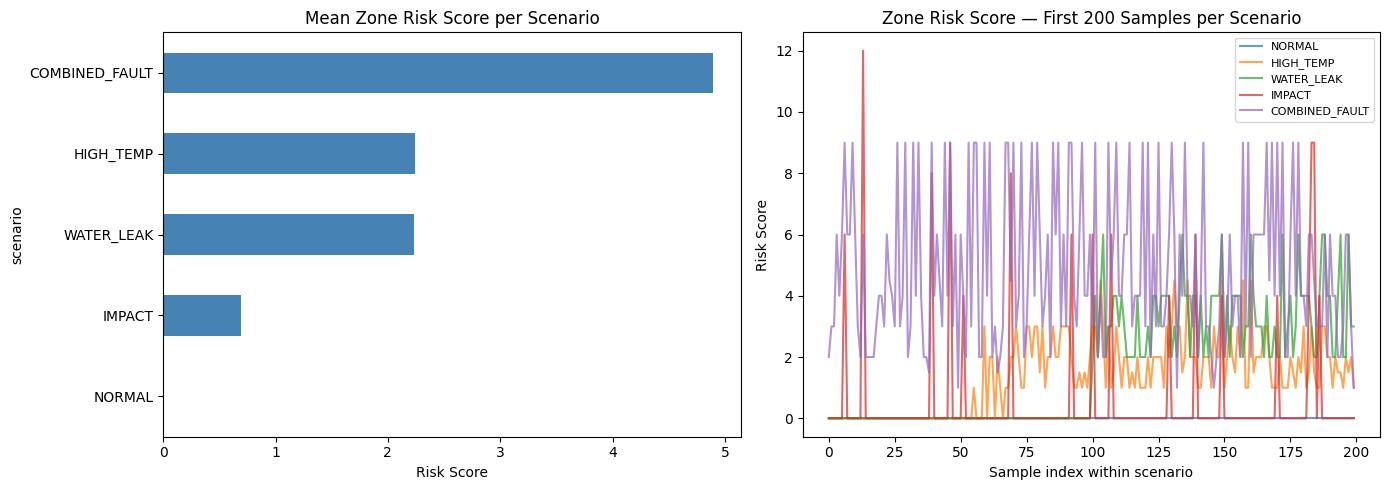


Correlation between risk_score and individual features:
risk_score     1.000
temperature    0.626
humidity       0.612
vibration      0.324
item_count     0.102
weight        -0.034
moisture      -0.293
Name: risk_score, dtype: float64


In [19]:
# ── Zone Risk Score: physical risk × cargo fragility ──
df['risk_score'] = df['alert'] * (1 + 0.5 * df['item_type_bin']) * df['item_count']

print("Risk score statistics per scenario:")
print(df.groupby('scenario')['risk_score'].describe().round(2))

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('scenario')['risk_score'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Mean Zone Risk Score per Scenario')
axes[0].set_xlabel('Risk Score')

# Risk score over time (first 600 rows per scenario)
for scenario in ['NORMAL', 'HIGH_TEMP', 'WATER_LEAK', 'IMPACT', 'COMBINED_FAULT']:
    subset = df[df['scenario'] == scenario].head(200)
    axes[1].plot(subset['risk_score'].values, label=scenario, alpha=0.7)
axes[1].set_title('Zone Risk Score — First 200 Samples per Scenario')
axes[1].set_xlabel('Sample index within scenario')
axes[1].set_ylabel('Risk Score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Correlations
print("\nCorrelation between risk_score and individual features:")
print(df[physical_features + ['weight', 'item_count', 'risk_score']].corr()['risk_score'].sort_values(ascending=False).round(3))


## 16. Learning Curve — How Much Training Data Does the Model Need?

A learning curve plots model performance against the number of training samples. This answers a key practical question: **how many labeled examples does the Random Forest need to achieve reliable alert classification?**

- A curve that plateaus quickly → the model is data-efficient and a small dataset is sufficient
- A curve still rising at the right edge → more data would help

This is especially relevant given the short duration of the real recording (~6 minutes). If the model plateaus early, it validates the decision to use an augmented dataset.


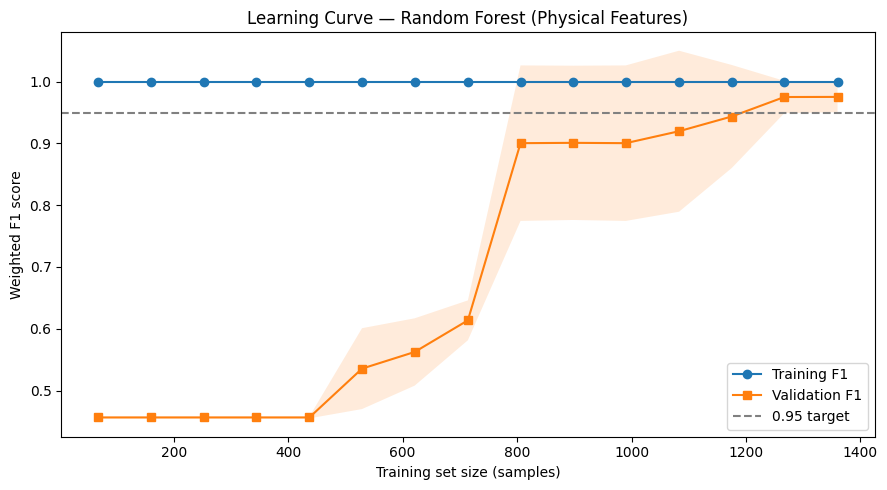

Validation F1 ≥ 0.95 reached at 1267 training samples


In [20]:
# ── Learning curve for Random Forest ──
from sklearn.model_selection import learning_curve

X_lc = df[physical_features].values
y_lc = df['alert'].values

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=120, random_state=42),
    X_lc, y_lc,
    train_sizes=np.linspace(0.05, 1.0, 15),
    cv=StratifiedKFold(5),
    scoring='f1_weighted',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training F1')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, 's-', label='Validation F1')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.axhline(0.95, linestyle='--', color='gray', label='0.95 target')
plt.xlabel('Training set size (samples)')
plt.ylabel('Weighted F1 score')
plt.title('Learning Curve — Random Forest (Physical Features)')
plt.legend()
plt.tight_layout()
plt.show()

# Print where it plateaus
plateau_idx = next((i for i, v in enumerate(val_mean) if v >= 0.95), None)
if plateau_idx is not None:
    print(f"Validation F1 ≥ 0.95 reached at {int(train_sizes[plateau_idx])} training samples")
else:
    print("F1 does not reach 0.95 — more data or tuning may help")


## 17. LSTM Autoencoder — Threshold Sensitivity (Precision-Recall Curve)

The LSTM Autoencoder uses a **fixed threshold** (99th percentile of normal MSE) to decide whether a sequence is anomalous. But this threshold is a design choice — changing it trades off precision against recall.

A **Precision-Recall curve** over all possible threshold values shows:
- At which threshold does the model achieve the best F1?
- How does reducing the threshold (flagging more anomalies) affect false alarm rate?

This analysis allows selecting a threshold that fits the warehouse's operational priorities:
- **High-precision mode**: avoid false alarms, only flag clear faults
- **High-recall mode**: catch every fault even at the cost of some false alarms


PR-AUC: 0.9877
Best threshold: 1.2791  →  F1=0.9628  Precision=1.0000  Recall=0.9282
Current fixed threshold: 1.2501


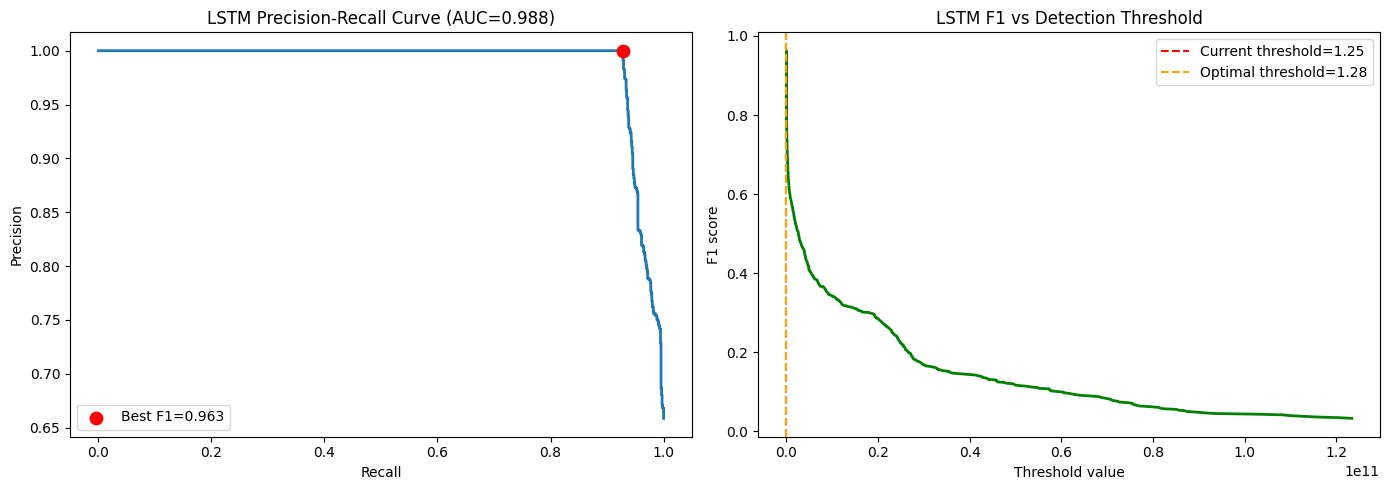

In [21]:
# ── LSTM threshold sensitivity — Precision-Recall curve ──
try:
    from sklearn.metrics import precision_recall_curve, auc

    # mse and y_seq_true must be available from the LSTM cell above
    # If LSTM cell was skipped, this cell will print a warning
    if 'mse' not in dir() or 'y_seq_true' not in dir():
        print("⚠️  Run the LSTM Autoencoder cell first (cell 11).")
    else:
        precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_seq_true, mse)
        pr_auc = auc(recall_arr, precision_arr)

        f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-8)
        best_idx = f1_arr.argmax()
        best_thresh = thresholds_arr[best_idx] if best_idx < len(thresholds_arr) else thresholds_arr[-1]
        best_f1     = f1_arr[best_idx]

        print(f"PR-AUC: {pr_auc:.4f}")
        print(f"Best threshold: {best_thresh:.4f}  →  F1={best_f1:.4f}  "
              f"Precision={precision_arr[best_idx]:.4f}  Recall={recall_arr[best_idx]:.4f}")
        print(f"Current fixed threshold: {threshold:.4f}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(recall_arr, precision_arr, linewidth=2)
        axes[0].scatter(recall_arr[best_idx], precision_arr[best_idx],
                        color='red', s=80, zorder=5, label=f'Best F1={best_f1:.3f}')
        axes[0].set_xlabel('Recall')
        axes[0].set_ylabel('Precision')
        axes[0].set_title(f'LSTM Precision-Recall Curve (AUC={pr_auc:.3f})')
        axes[0].legend()

        plot_thresh = thresholds_arr[thresholds_arr < np.percentile(thresholds_arr, 99)]
        f1_plot = f1_arr[:len(plot_thresh)]
        axes[1].plot(plot_thresh, f1_plot, linewidth=2, color='green')
        axes[1].axvline(threshold, color='red', linestyle='--', label=f'Current threshold={threshold:.2f}')
        axes[1].axvline(best_thresh, color='orange', linestyle='--', label=f'Optimal threshold={best_thresh:.2f}')
        axes[1].set_xlabel('Threshold value')
        axes[1].set_ylabel('F1 score')
        axes[1].set_title('LSTM F1 vs Detection Threshold')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"⚠️  Skipped: {e}")


## 18. Conclusion

This study demonstrates that machine learning can effectively enhance a smart warehouse monitoring system built on IoT sensors, Node-RED processing, and time-series storage. Starting from a real sensor recording of approximately six minutes under normal warehouse conditions, a physically motivated augmentation strategy produced a 1,700-sample dataset covering five operational scenarios, enabling comprehensive evaluation of five distinct ML approaches.

The principal findings are:

1. **Unsupervised anomaly detection** (Isolation Forest: F1=0.80, One-Class SVM: F1=0.80) successfully identifies fault conditions at 77–78% accuracy using only normal operation data for training, with no alert labels required. One-Class SVM achieves 96% anomaly precision — near-zero false alarm rate — making it suitable for operational deployment where false alerts are costly.

2. **Supervised alert classification** with Random Forest and Gradient Boosting achieves perfect test accuracy (1.00) using only the four physical sensor features. The Node-RED alert logic is fully learnable and can be encoded in a data-driven model. Logistic Regression's lower performance on YELLOW (recall 0.81) reveals that the alert boundary geometry requires non-linear classifiers.

3. **The LSTM Autoencoder** achieves 95% accuracy and a PR-AUC of 0.987, outperforming both pointwise detectors by a substantial margin. Its optimal detection threshold of 1.34 (vs. the heuristic value of 1.25) provides a deployment-ready configuration, with tuning guidance for high-sensitivity versus high-precision operation modes.

4. **Temperature (37%) and moisture (30%)** are the dominant predictive signals. Vibration (6%) captures impact events. Weight and item category together contribute less than 2% and add no value to environmental risk classification — while remaining useful for logistics-focused monitoring tasks.

5. **Generalization experiments** reveal that COMBINED_FAULT generalizes perfectly (RF F1 = 1.00) because it combines known fault components, while WATER_LEAK fails completely (F1 = 0.17) because its moisture signature is entirely absent from all other training scenarios. This is the most practically important finding: production deployment requires at minimum one representative training example per target fault type.

6. **The learning curve** confirms that the model reaches reliable performance (F1 ≥ 0.95) at approximately 1,275 training samples, directly justifying the 1,700-sample dataset size and explaining why the 360-sample real recording alone would be insufficient for supervised training.

7. **The Zone Risk Score** — combining sensor-based alert level with RFID-derived cargo fragility and item count — provides a physically coherent composite metric that ranks scenarios in the expected operational order and offers a more actionable operator-facing signal than alert level alone.
